## 1. 준비

In [1]:
!pip install koreanize-matplotlib -q

import numpy as np, pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, recall_score, precision_score, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt
import koreanize_matplotlib
print("준비 완료 ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 28.6 MB/s eta 0:00:00
준비 완료 ✅


## 2. 데이터 업로드
실행 후 **전세보증대위변제현황_깡통라벨.xlsx** 선택

In [2]:
from google.colab import files
up = files.upload()
DATA_PATH = list(up.keys())[0]

Saving 전세보증대위변제현황_깡통라벨.xlsx to 전세보증대위변제현황_깡통라벨.xlsx


## 3. 전처리

In [3]:
TARGET = "대위변제여부"; CAT = ["시도", "주택구분"]; SEED = 1
BEST = {"learning_rate": 0.018985510051859406, "num_leaves": 104, "max_depth": 9,
        "min_child_samples": 97, "subsample": 0.7610750361344647,
        "colsample_bytree": 0.6632114899553294, "reg_alpha": 0.009506920466340139,
        "reg_lambda": 0.005510071891943215}

df = pd.read_excel(DATA_PATH).drop(columns=["일련번호"])
dt = pd.to_datetime(df["보증완료월"])
df["보증완료연도"] = dt.dt.year
df["보증완료월"] = dt.dt.month
df = df.drop(columns=["깡통전세여부"])
for c in ["주택가액", "임대보증금액", "선순위채권금액", "평균보증금인상률", "시세대비보증금비율", "거래량"]:
    lo, hi = df[c].quantile(0.005), df[c].quantile(0.995)
    df[c] = df[c].clip(lo, hi)
for c in CAT:
    df[c] = df[c].astype("category")
X = df.drop(columns=[TARGET]); y = df[TARGET].astype(int)
print(f"데이터 {X.shape} | 양성(대위변제) {int(y.sum())}건 ({y.mean()*100:.1f}%)  ← 불균형!")

데이터 (50054, 19) | 양성(대위변제) 3777건 (7.5%)  ← 불균형!


## 4. 학습/평가 분리 (균형화 없이 그대로, stratify)

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train", X_tr.shape, "/ test", X_te.shape, "| 양성비율 유지", round(y_tr.mean(), 3))

train (40043, 19) / test (10011, 19) | 양성비율 유지 0.075


## 5. LightGBM 학습 (scale_pos_weight로 불균형 보정)

In [5]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
model = lgb.LGBMClassifier(n_estimators=400, scale_pos_weight=spw,
                           random_state=SEED, verbose=-1, **BEST)
model.fit(X_tr, y_tr, categorical_feature=CAT)
prob = model.predict_proba(X_te)[:, 1]
print(f"scale_pos_weight = {spw:.2f} (음성이 양성의 약 {spw:.0f}배라 양성에 가중치)")

scale_pos_weight = 12.25 (음성이 양성의 약 12배라 양성에 가중치)


## 6. AUC vs F1 (수치)
불균형에선 F1이 낮게 나오니 AUC와 함께 본다

In [6]:
auc = roc_auc_score(y_te, prob)
ap = average_precision_score(y_te, prob)
grid = np.linspace(prob.min(), prob.max(), 300)
f1s = [f1_score(y_te, (prob >= t).astype(int), zero_division=0) for t in grid]
bi = int(np.argmax(f1s)); best_t, best_f1 = grid[bi], f1s[bi]
pred = (prob >= 0.5).astype(int)

print("========== AUC vs F1 ==========")
print(f"  ROC-AUC   {auc:.3f}   ← 높음: 모델 구분력 우수 (임계값 무관)")
print(f"  PR-AUC    {ap:.3f}")
print(f"  F1 @0.5   {f1_score(y_te, pred):.3f}   ← 낮음: 불균형(양성 7.5%) 탓")
print(f"  F1 최적   {best_f1:.3f}  (임계값 {best_t:.2f})")

========== AUC vs F1 ==========
  ROC-AUC   0.887   ← 높음: 모델 구분력 우수 (임계값 무관)
  PR-AUC    0.556
  F1 @0.5   0.457   ← 낮음: 불균형(양성 7.5%) 탓
  F1 최적   0.547  (임계값 0.80)


## 7. AUC vs F1 비교 시각화
ROC 곡선(AUC) · PR 곡선 · 임계값별 F1

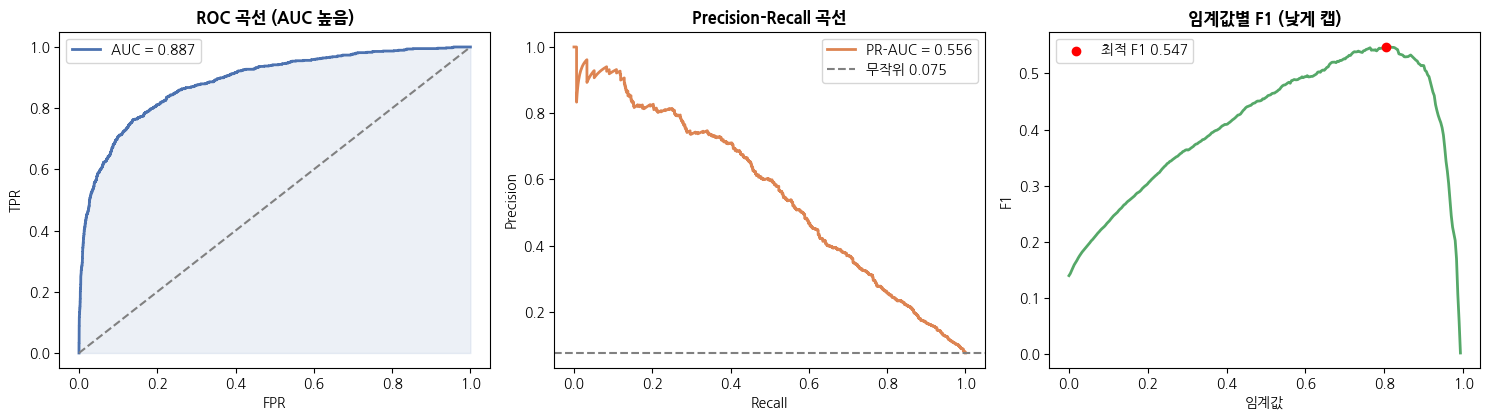

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
fpr, tpr, _ = roc_curve(y_te, prob)
ax[0].plot(fpr, tpr, color="#4c72b0", lw=2, label=f"AUC = {auc:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="gray"); ax[0].fill_between(fpr, tpr, alpha=0.1, color="#4c72b0")
ax[0].set_title("ROC 곡선 (AUC 높음)", weight="bold"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()

pr, rc, _ = precision_recall_curve(y_te, prob)
ax[1].plot(rc, pr, color="#dd8452", lw=2, label=f"PR-AUC = {ap:.3f}")
ax[1].axhline(y_te.mean(), ls="--", color="gray", label=f"무작위 {y_te.mean():.3f}")
ax[1].set_title("Precision-Recall 곡선", weight="bold"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()

ax[2].plot(grid, f1s, color="#55a868", lw=2)
ax[2].scatter([best_t], [best_f1], color="red", zorder=5, label=f"최적 F1 {best_f1:.3f}")
ax[2].set_title("임계값별 F1 (낮게 캡)", weight="bold"); ax[2].set_xlabel("임계값"); ax[2].set_ylabel("F1"); ax[2].legend()
plt.tight_layout(); plt.savefig("auc_f1_compare.png", dpi=120); plt.show()

## 8. 혼동행렬 (F1 최적 임계값 기준)

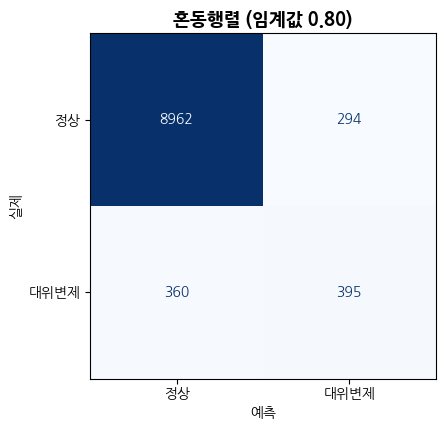

              precision    recall  f1-score   support

          정상      0.961     0.968     0.965      9256
        대위변제      0.573     0.523     0.547       755

    accuracy                          0.935     10011
   macro avg      0.767     0.746     0.756     10011
weighted avg      0.932     0.935     0.933     10011



In [8]:
pred_bt = (prob >= best_t).astype(int)
cm = confusion_matrix(y_te, pred_bt)
disp = ConfusionMatrixDisplay(cm, display_labels=["정상", "대위변제"])
fig, axc = plt.subplots(figsize=(5.2, 4.4))
disp.plot(ax=axc, cmap="Blues", values_format="d", colorbar=False)
axc.set_title(f"혼동행렬 (임계값 {best_t:.2f})", fontsize=13, weight="bold")
axc.set_xlabel("예측"); axc.set_ylabel("실제")
plt.tight_layout(); plt.savefig("confusion_matrix_before.png", dpi=130); plt.show()
print(classification_report(y_te, pred_bt, target_names=["정상", "대위변제"], digits=3))

## 9. 해석 — 왜 AUC와 F1을 함께 보나

| 지표 | 값(예) | 의미 |
|---|---|---|
| **ROC-AUC** | **0.89 (높음)** | 모델의 구분 실력. 임계값·클래스비율과 무관 → **모델은 우수** |
| **F1** | **0.5 (낮음)** | 불균형(양성 7.5%)이라 정밀도가 눌려 낮게 나옴 → **모델이 나쁜 게 아님** |

- 불균형 데이터는 **F1만 보면 모델을 과소평가**하게 됩니다.
- **PR 곡선**을 보면 recall을 올릴수록 precision이 급락 → F1이 잘 안 오르는 이유가 보임.
- 그래서 **AUC(모델 실력) + F1(운영 성능)을 함께** 보고 판단해야 합니다.
- (참고) 데이터를 50:50으로 **균형화**하면 F1이 0.8+로 오르지만 AUC는 그대로 → F1 상승은 대부분 '평가 방식' 효과.

# **SHAP으로 모델 해석하기**


In [ ]:
!pip install shap -q

import shap
shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_tr)

print("SHAP 값 계산 완료")


## Force Plot — 매물 1건 해석 (개별 해석 / Local)


In [ ]:
# 첫 번째 매물의 대위변제 예측 과정
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_tr.iloc[0, :])


In [ ]:
# 숫자로도 확인
print("[이 매물의 정보]")
print(X_tr.iloc[0, :])
print("\n[각 변수의 기여도(SHAP 값)]")
print(pd.Series(shap_values[0], index=X_tr.columns).round(3))


## Summary Plot — 전체 변수 중요도 (전체 해석 / Global)


In [ ]:
shap.summary_plot(shap_values, X_tr, plot_type="bar")
